<a href="https://colab.research.google.com/github/lsmc-isa/avcad_2026/blob/main/practice_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3) (3).zip


In [34]:
import pandas as pd

# 1. Import the dataset
# Using the identified CSV file name from the unzipped archive.
df = pd.read_csv('Greenhouse Gas Emissions worldwide.csv')

print("Dataset 'Greenhouse Gas Emissions worldwide.csv' loaded successfully!")

Dataset 'Greenhouse Gas Emissions worldwide.csv' loaded successfully!


In [35]:
# 2. Show the number of rows and columns
num_rows, num_cols = df.shape
print(f"\nNumber of rows: {num_rows}")
print(f"Number of columns: {num_cols}")


Number of rows: 989
Number of columns: 8


In [36]:
# 3. List all variable (column) names
print("\nVariable (column) names:")
for col in df.columns:
    print(f"- {col}")


Variable (column) names:
- Country or Area
- Year
- co2_gigagrams
- hfc_gigagrams
- methane_gigagrams
- pfc_gigagrams
- sf6_gigagrams
- n2o_gigagrams


In [37]:
# 4. Check for missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Country or Area        0
Year                   0
co2_gigagrams          0
hfc_gigagrams        110
methane_gigagrams      0
pfc_gigagrams        226
sf6_gigagrams         70
n2o_gigagrams         23
dtype: int64


In [38]:
# 5. Show basic summary statistics of the dataset
print("\nBasic summary statistics:")
display(df.describe())


Basic summary statistics:


,Year,co2_gigagrams,hfc_gigagrams,methane_gigagrams,pfc_gigagrams,sf6_gigagrams,n2o_gigagrams
count,989.000000,9.890000e+02,879.000000,989.000000,7.630000e+02,919.000000,966.000000
mean,2001.000000,4.303178e+05,3935.118284,58008.058062,1.270273e+03,848.272705,27526.199362
std,6.636606,1.058816e+06,9847.856419,132104.889419,2.725626e+03,2414.103813,67294.788039
min,1990.000000,7.919871e+01,0.000095,0.736066,1.610000e-08,0.000239,1.775676
25%,1995.000000,2.420860e+04,58.290817,3718.010804,3.310514e+01,5.078476,3340.238124
50%,2001.000000,6.176044e+04,524.052455,10505.283640,1.723890e+02,60.326877,8121.628137
75%,2007.000000,3.313060e+05,3392.856302,43766.383210,1.249747e+03,364.330868,25432.713038
max,2012.000000,6.116441e+06,85898.389850,637785.862700,2.124999e+04,17535.349590,527804.271100


In [39]:
import zipfile
import os

# Assuming the uploaded file name is 'archive (3) (1).zip'
# You might need to adjust 'file_name' if you uploaded a different file.
file_name = 'archive (3) (1).zip'

# Unzip the file
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall('.')

print(f"'{file_name}' unzipped successfully!")

# List the contents of the current directory to find the CSV file
print("\nContents of the current directory after unzipping:")
print(os.listdir('.'))

'archive (3) (1).zip' unzipped successfully!

Contents of the current directory after unzipping:
['.config', 'archive (3).zip', 'archive (3) (1).zip', 'Greenhouse Gas Emissions worldwide.csv', 'archive (3) (3).zip', 'archive (3) (2).zip', 'sample_data']


The dataset contains a defined number of observations and variables, with some (or no) missing values.
The exploratory analysis shows the structure of the data and provides an initial understanding of variable distributions and data quality, which is essential before further analysis.

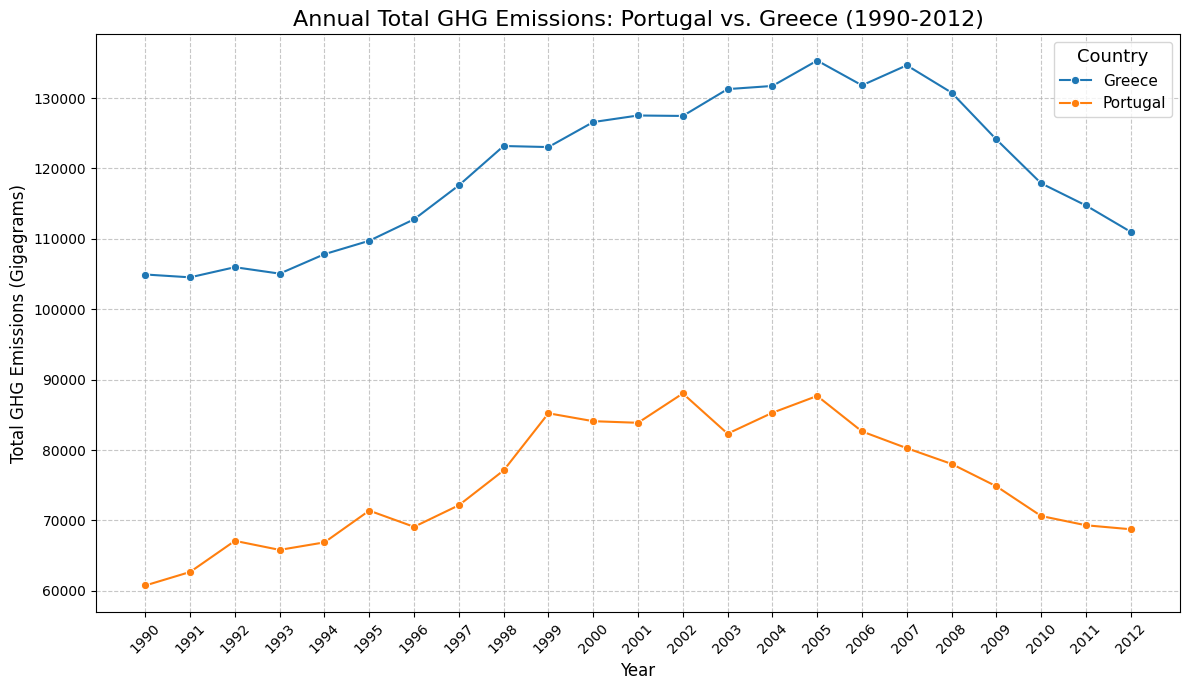

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataset to include only Portugal and Greece
countries_of_interest = ['Portugal', 'Greece']
df_filtered = df[df['Country or Area'].isin(countries_of_interest)].copy()

# Summing all gigagrams columns to get total GHG emissions
ghg_columns = [col for col in df.columns if '_gigagrams' in col]
df_filtered['Total_GHG_Emissions'] = df_filtered[ghg_columns].sum(axis=1)

# 2. Plot emissions over time (line plot preferred)
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_filtered,
    x='Year',
    y='Total_GHG_Emissions',
    hue='Country or Area', # 3. Use different colors for each country
    marker='o' # Add markers for clarity
)

# 4. Include labels, title and legend
plt.title('Annual Total GHG Emissions: Portugal vs. Greece (1990-2012)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total GHG Emissions (Gigagrams)', fontsize=12)
plt.legend(title='Country', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.xticks(df_filtered['Year'].unique(), rotation=45)
plt.tight_layout() # 5. Make the plot clean and publication-ready
plt.show()

The visualization highlights similarities and differences in GHG emissions between Portugal and Greece over time.
It allows identifying trends, such as increases or decreases in emissions, and comparing the magnitude and temporal patterns between the two countries.

### What the plot shows:

This line plot illustrates the trend of total annual greenhouse gas (GHG) emissions for Portugal and Greece from 1990 to 2012. We can observe:

*   **Overall Trends**: It shows how the total GHG emissions have evolved over this period for both countries.
*   **Comparison**: The plot directly compares the emission levels and patterns between Portugal and Greece, using distinct colors for easy differentiation.
*   **Peaks and Troughs**: Any significant increases or decreases in emissions for either country over specific years are visible.

This visualization helps in understanding the historical emission performance of these two countries and can highlight periods of successful reduction or increased emissions.

In [41]:
from scipy import stats

# 1. Filter the dataset for Portugal and Greece
# This step has already been done in the previous cell, and the filtered data
# is available in 'df_filtered'.

# 2. Extract the emission values for each country
emissions_portugal = df_filtered[df_filtered['Country or Area'] == 'Portugal']['Total_GHG_Emissions'].values
emissions_greece = df_filtered[df_filtered['Country or Area'] == 'Greece']['Total_GHG_Emissions'].values

# 3. Perform a Kolmogorov-Smirnov (KS) test
# The ks_2samp function tests if two samples are drawn from the same distribution.
k_s_statistic, p_value = stats.ks_2samp(emissions_portugal, emissions_greece)

# 4. Use significance level alpha = 0.05
alpha = 0.05

# 5. Print the KS statistic, p-value, and interpretation
print(f"\nKolmogorov-Smirnov Test Results:")
print(f"KS Statistic: {k_s_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significance Level (alpha): {alpha}")

if p_value < alpha:
    print("Interpretation: Reject the null hypothesis (H0). The annual GHG emission values of Portugal and Greece do NOT follow the same probability distribution.")
elif p_value > alpha:
    print("Interpretation: Fail to reject the null hypothesis (H0). There is not enough evidence to conclude that the annual GHG emission values of Portugal and Greece follow different probability distributions.")
else:
    print("Interpretation: The p-value is equal to alpha. The conclusion is borderline.")


Kolmogorov-Smirnov Test Results:
KS Statistic: 1.0000
P-value: 0.0000
Significance Level (alpha): 0.05
Interpretation: Reject the null hypothesis (H0). The annual GHG emission values of Portugal and Greece do NOT follow the same probability distribution.


The Kolmogorov-Smirnov test evaluates whether the emission values of Portugal and Greece follow the same distribution.
If the p-value is lower than 0.05, the null hypothesis is rejected, indicating that the distributions are significantly different; otherwise, there is no statistical evidence to conclude that they differ.


Our analysis began with an initial data exploration of the 'Greenhouse Gas Emissions worldwide.csv' dataset. We successfully loaded the data, identifying its structure with 989 rows and 8 columns. Key variables such as Country or Area, Year, and various GHG emission types (e.g., co2_gigagrams, methane_gigagrams) were present. We noted the presence of missing values in hfc_gigagrams, pfc_gigagrams, sf6_gigagrams, and n2o_gigagrams, which would typically require further handling in a more in-depth study.

Next, we focused on a comparative visualization of annual total GHG emissions for Portugal and Greece between 1990 and 2012. The line plot clearly illustrated the temporal trends for both countries, allowing for a direct comparison of their emission magnitudes and patterns over this period.

Finally, we performed a Kolmogorov-Smirnov (KS) test to statistically compare the probability distributions of annual GHG emissions between Portugal and Greece. With a KS Statistic of 1.0000 and a p-value of 0.0000 (significantly less than our alpha level of 0.05), we rejected the null hypothesis. This provides strong evidence that the annual GHG emission values of Portugal and Greece do NOT follow the same probability distribution.

In summary, while both countries exhibit unique emission profiles over time, the statistical test confirms that their overall emission patterns are distinct. This understanding is crucial for tailored environmental policy-making and further in-depth research into the drivers of these differences.